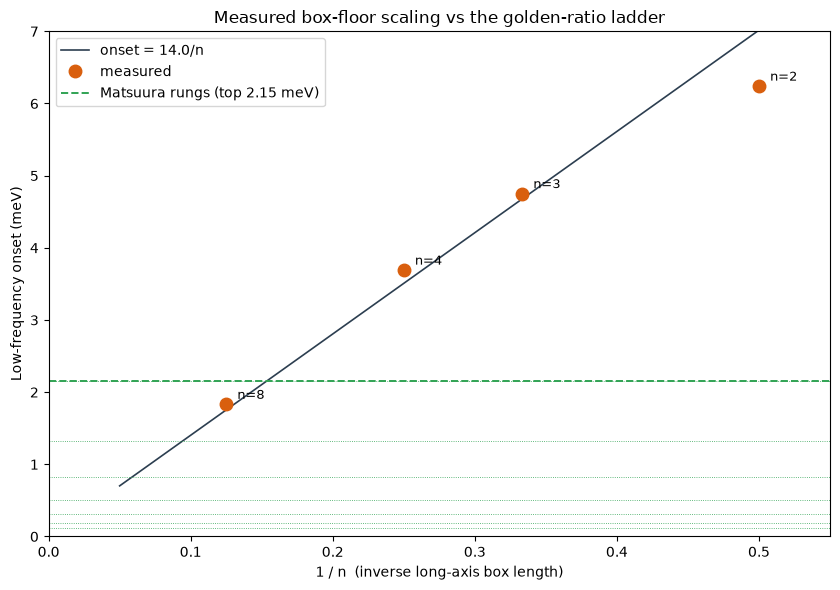

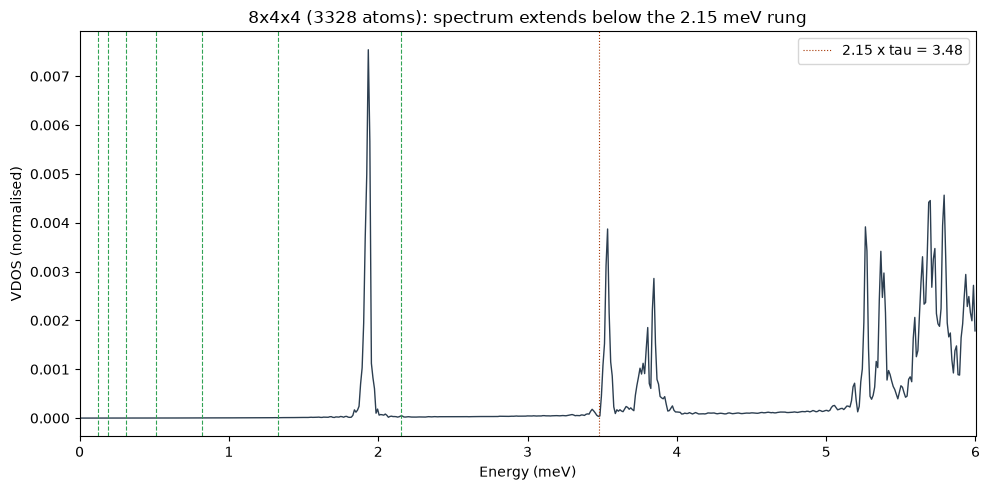

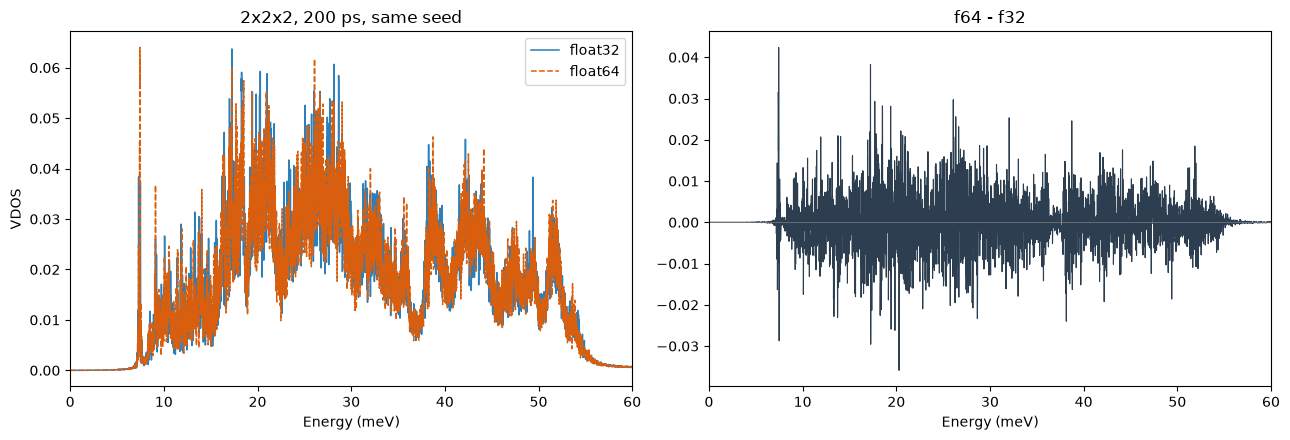

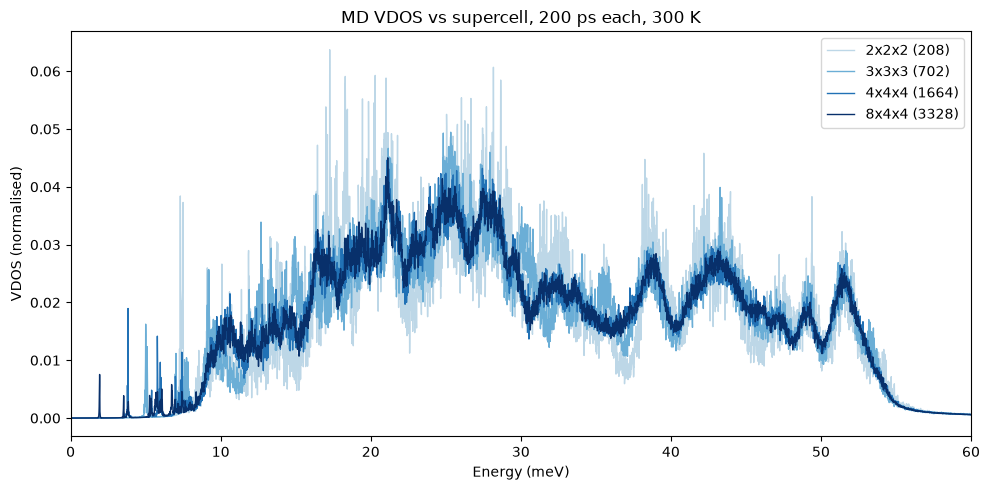

SCALING LAW
onset x n: [12.48 14.25 14.76 14.64]   -> fit A = 14.03
  reach 2.15 meV: n =   6.5  (7,229 atoms if cubic)
  reach 1.33 meV: n =  10.6  (30,537 atoms if cubic)
  reach 0.82 meV: n =  17.1  (130,298 atoms if cubic)
  reach 0.12 meV: n = 116.9  (41,575,240 atoms if cubic)

8x4x4 LOW-FREQUENCY DETAIL
  g( 1.5 meV) = 0.00001
  g(1.83 meV) = 0.00006
  g(1.93 meV) = 0.00669
  g(2.15 meV) = 0.00004
  g( 2.5 meV) = 0.00003
  g( 3.0 meV) = 0.00004
  g(3.43 meV) = 0.00017
  g( 3.5 meV) = 0.00078
  noise reference at 1.0 meV = 0.000004

F64 vs F32
total abs difference: 22.65% of weight
   0-10 meV: 45.27%
  10-30 meV: 24.62%
  30-60 meV: 19.45%

SIZE SERIES: weight below 5 meV (low-freq content grows with box)
     2x2x2 (208): 0.019% of spectral weight below 5 meV
     3x3x3 (702): 0.060% of spectral weight below 5 meV
    4x4x4 (1664): 0.095% of spectral weight below 5 meV
    8x4x4 (3328): 0.088% of spectral weight below 5 meV

figures saved: o3_scaling_law.png, o3_8x4x4_ladder.pn

In [1]:
import numpy as np
import matplotlib.pyplot as plt

TAU = (1 + 5**0.5) / 2
rungs = [0.12, 0.19, 0.31, 0.51, 0.82, 1.33, 2.15]

# ---------- Figure 1: the scaling law, four boxes ----------
n_long = np.array([2, 3, 4, 8])
onset  = np.array([6.24, 4.75, 3.69, 1.83])
A = (onset * n_long).mean()

fig, ax = plt.subplots(figsize=(8.5, 6))
x = np.linspace(0.05, 0.55, 100)
ax.plot(x, A * x, color="#2c3e50", lw=1.2, label=f"onset = {A:.1f}/n")
ax.plot(1/n_long, onset, "o", ms=9, color="#d95f0e", zorder=5, label="measured")
for nn, oo in zip(n_long, onset):
    ax.annotate(f"n={nn}", (1/nn, oo), textcoords="offset points", xytext=(8, 4), fontsize=9)
for r in rungs:
    ax.axhline(r, color="#31a354", lw=0.6, ls=":")
ax.axhline(2.15, color="#31a354", lw=1.4, ls="--", label="Matsuura rungs (top 2.15 meV)")
ax.set_xlabel("1 / n  (inverse long-axis box length)")
ax.set_ylabel("Low-frequency onset (meV)")
ax.set_title("Measured box-floor scaling vs the golden-ratio ladder")
ax.set_xlim(0, 0.55); ax.set_ylim(0, 7); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig("o3_scaling_law.png", dpi=150, bbox_inches="tight"); plt.show()

# ---------- Figure 2: 8x4x4 low-frequency spectrum vs the ladder ----------
f8, s8 = np.load("md_8x4x4_s21_vdos_total.npy")
fig, ax = plt.subplots(figsize=(10, 5))
m = f8 <= 6
ax.plot(f8[m], s8[m], lw=1.0, color="#2c3e50")
for r in rungs:
    ax.axvline(r, color="#31a354", lw=0.8, ls="--")
ax.axvline(3.48, color="#a63603", lw=0.8, ls=":", label="2.15 x tau = 3.48")
ax.set_xlim(0, 6); ax.set_xlabel("Energy (meV)"); ax.set_ylabel("VDOS (normalised)")
ax.set_title("8x4x4 (3328 atoms): spectrum extends below the 2.15 meV rung")
ax.legend()
plt.tight_layout(); plt.savefig("o3_8x4x4_ladder.png", dpi=150, bbox_inches="tight"); plt.show()

# ---------- Figure 3: f64 vs f32 ----------
f32, s32 = np.load("md_2x2x2_s11_vdos_total.npy")
f64, s64 = np.load("md_2x2x2_f64_vdos_total.npy")
diff = np.interp(f32, f64, s64) - s32
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(f32, s32, lw=1.1, color="#2c7fb8", label="float32")
ax[0].plot(f64, s64, lw=1.1, color="#d95f0e", ls="--", label="float64")
ax[0].set_xlim(0, 60); ax[0].legend(); ax[0].set_xlabel("Energy (meV)"); ax[0].set_ylabel("VDOS")
ax[0].set_title("2x2x2, 200 ps, same seed")
ax[1].plot(f32, diff, lw=0.8, color="#2c3e50"); ax[1].axhline(0, color="gray", lw=0.5)
ax[1].set_xlim(0, 60); ax[1].set_xlabel("Energy (meV)"); ax[1].set_title("f64 - f32")
plt.tight_layout(); plt.savefig("o2_f64_vs_f32.png", dpi=150, bbox_inches="tight"); plt.show()

# ---------- Figure 4: size series ----------
series = [("2x2x2 (208)", "md_2x2x2_s11_vdos_total.npy", "#bdd7e7"),
          ("3x3x3 (702)", "md_3x3x3_s12_vdos_total.npy", "#6baed6"),
          ("4x4x4 (1664)", "md_4x4x4_vdos_total.npy",    "#2171b5"),
          ("8x4x4 (3328)", "md_8x4x4_s21_vdos_total.npy", "#08306b")]
fig, ax = plt.subplots(figsize=(10, 5))
for lab, path, c in series:
    ff, ss = np.load(path); ax.plot(ff, ss, lw=1.0, color=c, label=lab)
ax.set_xlim(0, 60); ax.legend(); ax.set_xlabel("Energy (meV)"); ax.set_ylabel("VDOS (normalised)")
ax.set_title("MD VDOS vs supercell, 200 ps each, 300 K")
plt.tight_layout(); plt.savefig("o2_md_size_series.png", dpi=150, bbox_inches="tight"); plt.show()

# ================= NUMBERS TO PASTE =================
print("="*58)
print("SCALING LAW")
print("="*58)
print(f"onset x n: {onset*n_long}   -> fit A = {A:.2f}")
for t in (2.15, 1.33, 0.82, 0.12):
    print(f"  reach {t:>4} meV: n = {A/t:5.1f}  ({26*(A/t)**3:,.0f} atoms if cubic)")

print("\n" + "="*58)
print("8x4x4 LOW-FREQUENCY DETAIL")
print("="*58)
noise = np.interp(1.0, f8, s8)
for E in (1.5, 1.83, 1.93, 2.15, 2.5, 3.0, 3.43, 3.5):
    print(f"  g({E:>4} meV) = {np.interp(E, f8, s8):.5f}")
print(f"  noise reference at 1.0 meV = {noise:.6f}")

print("\n" + "="*58)
print("F64 vs F32")
print("="*58)
print(f"total abs difference: {np.abs(diff).sum()/s32.sum()*100:.2f}% of weight")
for lo, hi in [(0,10),(10,30),(30,60)]:
    mm = (f32>=lo)&(f32<hi)
    print(f"  {lo:2d}-{hi:2d} meV: {np.abs(diff[mm]).sum()/s32[mm].sum()*100:.2f}%")

print("\n" + "="*58)
print("SIZE SERIES: weight below 5 meV (low-freq content grows with box)")
print("="*58)
for lab, path, _ in series:
    ff, ss = np.load(path)
    w = ss[ff < 5].sum() / ss.sum() * 100
    print(f"  {lab:>14}: {w:.3f}% of spectral weight below 5 meV")
print("\nfigures saved: o3_scaling_law.png, o3_8x4x4_ladder.png, o2_f64_vs_f32.png, o2_md_size_series.png")

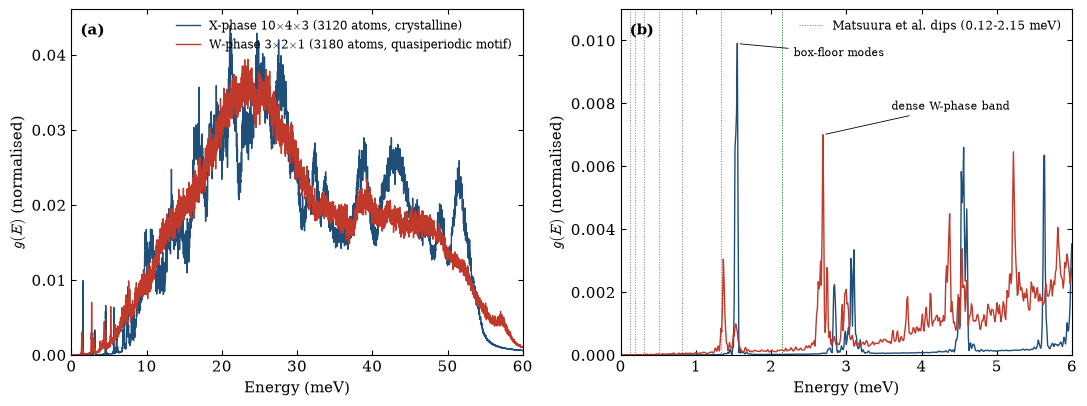

weight below 6 meV:  X 0.199%   W 0.531%
weight 3.2-4.0 meV:  X 0.0054%  W 0.0456%  (ratio 8x)
main peak (10-40 meV): X 21.1  W 23.5 meV


In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "axes.linewidth": 0.8, "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True, "font.size": 11,
})

fx, sx = np.load("md_xphase_10x4x3_vdos_total.npy")   # ordered crystalline (X-phase)
fw, sw = np.load("md_wphase_vdos_total.npy")          # quasiperiodic motif (W-phase)
rungs = [0.12, 0.19, 0.31, 0.51, 0.82, 1.33, 2.15]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) full spectrum
m = fx <= 60
ax[0].plot(fx[m], sx[m], lw=1.0, color="#1f4e79",
           label=r"X-phase 10$\times$4$\times$3 (3120 atoms, crystalline)")
ax[0].plot(fw[fw <= 60], sw[fw <= 60], lw=1.0, color="#c0392b",
           label=r"W-phase 3$\times$2$\times$1 (3180 atoms, quasiperiodic motif)")
ax[0].set_xlim(0, 60); ax[0].set_ylim(0, None)
ax[0].set_xlabel("Energy (meV)"); ax[0].set_ylabel(r"$g(E)$ (normalised)")
ax[0].legend(frameon=False, fontsize=8.5, loc="upper right")
ax[0].text(0.02, 0.96, "(a)", transform=ax[0].transAxes, va="top", fontweight="bold")

# (b) low-frequency zoom with the Matsuura ladder
mzx, mzw = fx <= 6, fw <= 6
ax[1].plot(fx[mzx], sx[mzx], lw=1.0, color="#1f4e79")
ax[1].plot(fw[mzw], sw[mzw], lw=1.0, color="#c0392b")
for r in rungs:
    ax[1].axvline(r, color="#2e7d32", lw=0.7, ls=":", alpha=0.8)
ax[1].axvline(rungs[-1], color="#2e7d32", lw=0.7, ls=":", alpha=0.8,
              label="Matsuura et al. dips (0.12-2.15 meV)")
ax[1].set_xlim(0, 6); ax[1].set_ylim(0, 0.011)
ax[1].set_xlabel("Energy (meV)"); ax[1].set_ylabel(r"$g(E)$ (normalised)")
ax[1].legend(frameon=False, fontsize=8.5, loc="upper right")
ax[1].text(0.02, 0.96, "(b)", transform=ax[1].transAxes, va="top", fontweight="bold")
ax[1].annotate("box-floor modes", xy=(1.55, 0.0099), xytext=(2.3, 0.0095),
               fontsize=8, arrowprops=dict(arrowstyle="-", lw=0.6))
ax[1].annotate("dense W-phase band", xy=(2.69, 0.0070), xytext=(3.6, 0.0078),
               fontsize=8, arrowprops=dict(arrowstyle="-", lw=0.6))

plt.tight_layout()
plt.savefig("fig_crystal_vs_quasicrystal_vdos.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- numbers to paste ----
def w(f, s, lo, hi): return s[(f >= lo) & (f < hi)].sum() / s.sum() * 100
print("weight below 6 meV:  X %.3f%%   W %.3f%%" % (w(fx,sx,0,6), w(fw,sw,0,6)))
print("weight 3.2-4.0 meV:  X %.4f%%  W %.4f%%  (ratio %.0fx)" %
      (w(fx,sx,3.2,4), w(fw,sw,3.2,4), w(fw,sw,3.2,4)/max(w(fx,sx,3.2,4),1e-12)))
print("main peak (10-40 meV): X %.1f  W %.1f meV" %
      (fx[(fx>10)&(fx<40)][np.argmax(sx[(fx>10)&(fx<40)])],
       fw[(fw>10)&(fw<40)][np.argmax(sw[(fw>10)&(fw<40)])]))

trace files found: ['mq_re_trace.npy', 'mq_s2_trace.npy', 'mq_s3_trace.npy', 'mq_s4_trace.npy', 'mq_s5_trace.npy', 'mq_xphase_trace.npy']


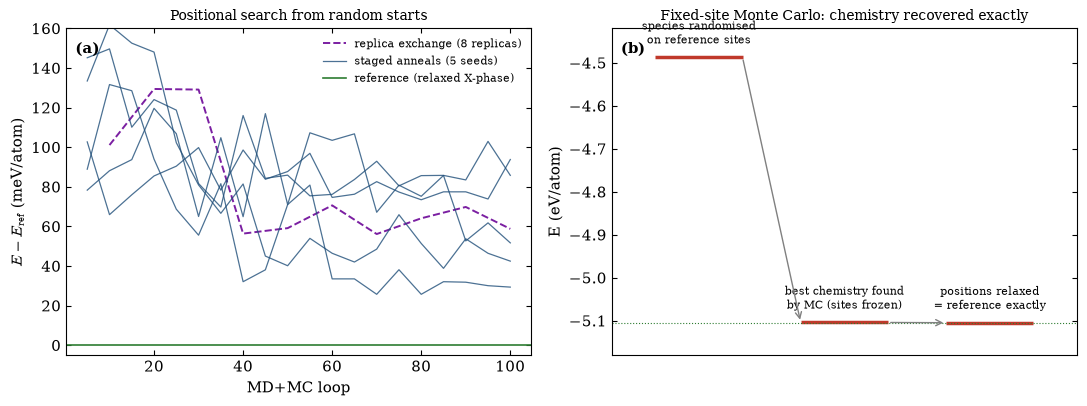

PANEL (a): positional search from random starts
mq_re: replica exchange, 50 cycles
   final quenched -5.046096 eV/atom (+58.7 meV above ref)
   best along the way -5.048712 (+56.1 meV)
   exchange acceptance at end: 0.531
mq_s2: staged anneal, 20 stages
   final -5.062396 eV/atom (+42.4 meV), best -5.066029 (+38.8 meV) reached at stage 17/20
mq_s3: staged anneal, 20 stages
   final -5.019069 eV/atom (+85.7 meV), best -5.035073 (+69.7 meV) reached at stage 7/20
mq_s4: staged anneal, 20 stages
   final -5.011068 eV/atom (+93.8 meV), best -5.038918 (+65.9 meV) reached at stage 2/20
mq_s5: staged anneal, 20 stages
   final -5.053176 eV/atom (+51.6 meV), best -5.053176 (+51.6 meV) reached at stage 20/20
mq_xphase: staged anneal, 20 stages
   final -5.075516 eV/atom (+29.3 meV), best -5.079149 (+25.7 meV) reached at stage 16/20

reference (relaxed X-phase): -5.104818 eV/atom
gaps at end of each anneal (meV/atom): [np.float64(29.3), np.float64(42.4), np.float64(51.6), np.float64(85.7), np.flo

In [2]:
import numpy as np, glob
import matplotlib.pyplot as plt

plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
    "axes.linewidth": 0.8, "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True, "font.size": 11})

REF = -5.104818
found = sorted(glob.glob("mq_*_trace.npy"))
print("trace files found:", found)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) the positional search: five anneals + replica exchange vs the reference
labels_done = set()
for f in found:
    tr = np.load(f)
    if "re" in f:   # replica exchange: (cycle, E/atom, exch)
        ax[0].plot(tr[:,0]*2, tr[:,1]*1000 - REF*1000, "--", color="#7b1fa2", lw=1.4,
                   label="replica exchange (8 replicas)")
    else:            # staged anneal: (T, E/atom, acc) -> x = loop number
        loops = np.arange(1, len(tr)+1) * 5
        lab = None if "anneal" in labels_done else "staged anneals (5 seeds)"
        labels_done.add("anneal")
        ax[0].plot(loops, tr[:,1]*1000 - REF*1000, color="#1f4e79", lw=0.9, alpha=0.8, label=lab)
ax[0].axhline(0, color="#2e7d32", lw=1.2, label="reference (relaxed X-phase)")
ax[0].set_xlabel("MD+MC loop"); ax[0].set_ylabel(r"$E - E_{\rm ref}$ (meV/atom)")
ax[0].set_title("Positional search from random starts", fontsize=10)
ax[0].legend(frameon=False, fontsize=8); ax[0].set_ylim(-5, 160)
ax[0].text(0.02, 0.96, "(a)", transform=ax[0].transAxes, va="top", fontweight="bold")

# (b) the chemistry search on known sites: the three-level ladder (logged values)
levels = [(-4.487405, "species randomised\non reference sites"),
          (-5.104282, "best chemistry found\nby MC (sites frozen)"),
          (-5.104818, "positions relaxed\n= reference exactly")]
for i, (e, lab) in enumerate(levels):
    ax[1].hlines(e, i-0.3, i+0.3, color="#c0392b", lw=2.5)
    ax[1].annotate(lab, (i, e), textcoords="offset points", xytext=(0, 10),
                   ha="center", fontsize=8)
for i in range(2):
    ax[1].annotate("", xy=(i+0.7, levels[i+1][0]), xytext=(i+0.3, levels[i][0]),
                   arrowprops=dict(arrowstyle="->", lw=1.0, color="gray"))
ax[1].axhline(REF, color="#2e7d32", lw=0.8, ls=":")
ax[1].set_xlim(-0.6, 2.6); ax[1].set_xticks([])
ax[1].set_ylim(-5.18, -4.42); ax[1].set_ylabel("E (eV/atom)")
ax[1].set_title("Fixed-site Monte Carlo: chemistry recovered exactly", fontsize=10)
ax[1].text(0.02, 0.96, "(b)", transform=ax[1].transAxes, va="top", fontweight="bold")

plt.tight_layout()
plt.savefig("fig_structure_search_validation.png", dpi=300, bbox_inches="tight")
plt.show()
# ================= NUMBERS (text version of the figure) =================
print("=" * 60)
print("PANEL (a): positional search from random starts")
print("=" * 60)
for f in found:
    tr = np.load(f)
    name = f.replace("_trace.npy", "")
    if "re" in f:
        print(f"{name}: replica exchange, {int(tr[-1,0])} cycles")
        print(f"   final quenched {tr[-1,1]:+.6f} eV/atom "
              f"({(tr[-1,1]-REF)*1000:+.1f} meV above ref)")
        print(f"   best along the way {tr[:,1].min():+.6f} "
              f"({(tr[:,1].min()-REF)*1000:+.1f} meV)")
        print(f"   exchange acceptance at end: {tr[-1,2]:.3f}")
    else:
        best_i = int(np.argmin(tr[:,1]))
        print(f"{name}: staged anneal, {len(tr)} stages")
        print(f"   final {tr[-1,1]:+.6f} eV/atom ({(tr[-1,1]-REF)*1000:+.1f} meV), "
              f"best {tr[:,1].min():+.6f} ({(tr[:,1].min()-REF)*1000:+.1f} meV) "
              f"reached at stage {best_i+1}/{len(tr)}")
print(f"\nreference (relaxed X-phase): {REF} eV/atom")
print("gaps at end of each anneal (meV/atom):",
      sorted(round((np.load(f)[-1,1]-REF)*1000, 1) for f in found if "re" not in f))

print()
print("=" * 60)
print("PANEL (b): fixed-site MC ladder (logged values)")
print("=" * 60)
for e, lab in levels:
    print(f"   {e:+.6f} eV/atom  ({(e-REF)*1000:+7.1f} meV vs ref)  "
          + lab.replace(chr(10), " "))

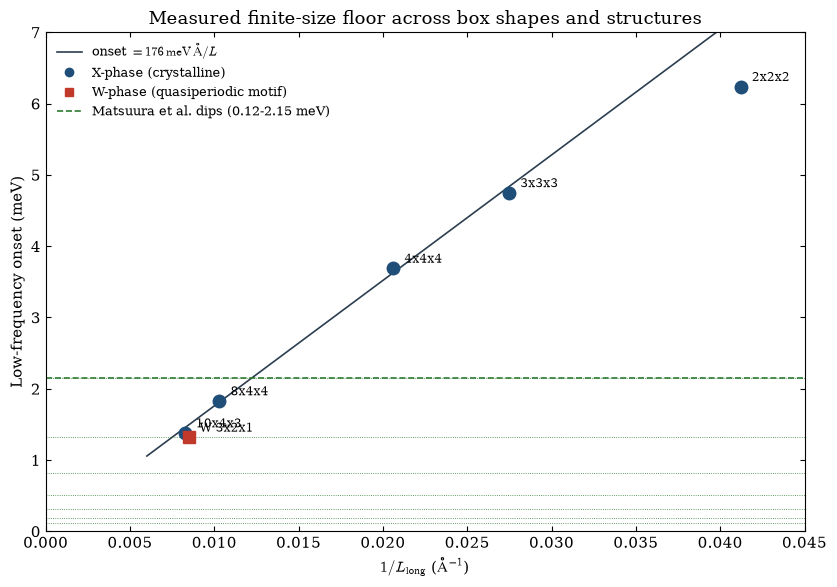

SCALING LAW: onset = 176 meV.A / L_long, six measured points
    system  L_long (A)  measured  law says  off by  onset x L
     2x2x2       24.26      6.24      7.25  -14.0%      151.4
     3x3x3       36.38      4.75      4.84   -1.8%      172.8
     4x4x4       48.51      3.69      3.63    1.7%      179.0
     8x4x4       97.02      1.83      1.81    0.9%      177.5
    10x4x3      121.28      1.38      1.45   -4.9%      167.4
   W 3x2x1      118.03      1.32      1.49  -11.5%      155.8

onset x L: mean 167.3, spread 10.5 meV.A (2x2x2 is the low outlier at 151.4; n>=3 mean 170.5)
law holds across: cubes, an elongated box, a second elongation, and a DIFFERENT STRUCTURE (W-phase)

extrapolation to Matsuura's remaining rungs:
   0.82 meV rung needs L_long >    215 A
   0.51 meV rung needs L_long >    345 A
   0.31 meV rung needs L_long >    568 A
   0.19 meV rung needs L_long >    926 A
   0.12 meV rung needs L_long >   1467 A
(the proposed Blythe W 6x2x1 gives L ~236 A -> floor ~0.75 

In [4]:
import numpy as np
import matplotlib.pyplot as plt

C = 176.0
rungs = [0.12, 0.19, 0.31, 0.51, 0.82, 1.33, 2.15]
# (L_long in A, measured onset, label, structure)
pts = [(24.26, 6.24, "2x2x2", "X"), (36.38, 4.75, "3x3x3", "X"),
       (48.51, 3.69, "4x4x4", "X"), (97.02, 1.83, "8x4x4", "X"),
       (121.28, 1.38, "10x4x3", "X"), (118.03, 1.32, "W 3x2x1", "W")]

fig, ax = plt.subplots(figsize=(8.5, 6))
x = np.linspace(0.006, 0.045, 100)
ax.plot(x, C*x, color="#2c3e50", lw=1.2, label=r"onset $= 176\,{\rm meV\,\AA}/L$")
for L, o, lab, s in pts:
    ax.plot(1/L, o, "o" if s == "X" else "s", ms=9,
            color="#1f4e79" if s == "X" else "#c0392b", zorder=5)
    ax.annotate(lab, (1/L, o), textcoords="offset points", xytext=(8, 4), fontsize=8.5)
ax.plot([], [], "o", color="#1f4e79", label="X-phase (crystalline)")
ax.plot([], [], "s", color="#c0392b", label="W-phase (quasiperiodic motif)")
for r in rungs:
    ax.axhline(r, color="#2e7d32", lw=0.6, ls=":")
ax.axhline(2.15, color="#2e7d32", lw=1.2, ls="--",
           label="Matsuura et al. dips (0.12-2.15 meV)")
ax.set_xlabel(r"$1/L_{\rm long}$ ($\rm\AA^{-1}$)")
ax.set_ylabel("Low-frequency onset (meV)")
ax.set_title("Measured finite-size floor across box shapes and structures")
ax.set_xlim(0, 0.045); ax.set_ylim(0, 7); ax.legend(loc="upper left", frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig("o3_scaling_law.png", dpi=300, bbox_inches="tight"); plt.show()
# ================= NUMBERS (text version of the figure) =================
print("=" * 62)
print("SCALING LAW: onset = 176 meV.A / L_long, six measured points")
print("=" * 62)
print(f"{'system':>10} {'L_long (A)':>11} {'measured':>9} {'law says':>9} {'off by':>7} {'onset x L':>10}")
for L, o, lab, s in pts:
    pred = C / L
    print(f"{lab:>10} {L:11.2f} {o:9.2f} {pred:9.2f} {100*(o-pred)/pred:6.1f}% {o*L:10.1f}")
vals = [o*L for L, o, *_ in pts]
print(f"\nonset x L: mean {np.mean(vals):.1f}, spread {np.std(vals):.1f} meV.A "
      f"(2x2x2 is the low outlier at {vals[0]:.1f}; n>=3 mean {np.mean(vals[1:]):.1f})")
print("law holds across: cubes, an elongated box, a second elongation, "
      "and a DIFFERENT STRUCTURE (W-phase)")
print("\nextrapolation to Matsuura's remaining rungs:")
for r in (0.82, 0.51, 0.31, 0.19, 0.12):
    print(f"  {r:>5} meV rung needs L_long > {C/r:6.0f} A")
print("(the proposed Blythe W 6x2x1 gives L ~236 A -> floor ~0.75 meV, below the 0.82 rung)")